# Determinants of Patient Satisfaction in Healthcare Facilities

## Objective
The aim of this project is to analyze how different factors influence patient satisfaction across hospitals using HCAHPS data.

Instead of using a heavily reduced cleaned dataset, we applied a more flexible cleaning strategy to retain as much data as possible while ensuring data quality. This allows a more robust and representative analysis.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_ind, chi2_contingency

In [15]:
df = pd.read_csv("cms_hospital_patient_satisfaction_2016.csv")

print(df.shape)
df.head()

(264385, 43)


,Facility ID,Facility Name,Address,City,State,ZIP Code,County Name,Phone Number,HCAHPS Measure ID,HCAHPS Question,...,Readmission national comparison,Readmission national comparison footnote,Patient experience national comparison,Patient experience national comparison footnote,Effectiveness of care national comparison,Effectiveness of care national comparison footnote,Timeliness of care national comparison,Timeliness of care national comparison footnote,Efficient use of medical imaging national comparison,Efficient use of medical imaging national comparison footnote
0,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_STAR_RATING,Summary star rating,...,Same as the National average,NaN,Below the National average,NaN,Same as the National average,NaN,Same as the National average,NaN,Same as the National average,NaN
1,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_HSP_A_P,Patients who reported that their room and bath...,...,Same as the National average,NaN,Below the National average,NaN,Same as the National average,NaN,Same as the National average,NaN,Same as the National average,NaN
2,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_HSP_SN_P,Patients who reported that their room and bath...,...,Same as the National average,NaN,Below the National average,NaN,Same as the National average,NaN,Same as the National average,NaN,Same as the National average,NaN
3,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_HSP_U_P,Patients who reported that their room and bath...,...,Same as the National average,NaN,Below the National average,NaN,Same as the National average,NaN,Same as the National average,NaN,Same as the National average,NaN
4,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_LINEAR_SCORE,Cleanliness - linear mean score,...,Same as the National average,NaN,Below the National average,NaN,Same as the National average,NaN,Same as the National average,NaN,Same as the National average,NaN


In [16]:
# Replace text with NaN
df.replace(["Not Available", "Not Applicable"], pd.NA, inplace=True)

# Convert to numeric
df['Hospital overall rating'] = pd.to_numeric(df['Hospital overall rating'], errors='coerce')
df['HCAHPS Answer Percent'] = pd.to_numeric(df['HCAHPS Answer Percent'], errors='coerce')

# Keep useful rows
df_clean = df.dropna(subset=['Hospital overall rating', 'HCAHPS Answer Percent'], how='all')

print(df_clean.shape)

(215680, 43)


The dataset contained many missing and non-numeric values such as "Not Available".  
Instead of removing all incomplete rows, a flexible cleaning strategy was applied to retain as much data as possible while ensuring data quality.

In [17]:
counts = df_clean['Facility Name'].value_counts()

df_filtered = df_clean[df_clean['Facility Name'].isin(counts[counts > 30].index)]

print(df_filtered.shape)

(215680, 43)


Hospitals with very few observations were removed to ensure reliable analysis.  
This helps avoid biased results from insufficient data.

In [18]:
df_pivot = df_filtered.pivot_table(
    index='Facility Name',
    columns='HCAHPS Question',
    values='HCAHPS Answer Percent',
    aggfunc='mean'
)

df_pivot = df_pivot.reset_index()

df_pivot.head()

HCAHPS Question,Facility Name,"Patients who ""Strongly Agree"" they understood their care when they left the hospital",Patients who gave their hospital a rating of 6 or lower on a scale from 0 (lowest) to 10 (highest),Patients who gave their hospital a rating of 7 or 8 on a scale from 0 (lowest) to 10 (highest),Patients who gave their hospital a rating of 9 or 10 on a scale from 0 (lowest) to 10 (highest),"Patients who reported NO, they would probably not or definitely not recommend the hospital","Patients who reported YES, they would definitely recommend the hospital","Patients who reported YES, they would probably recommend the hospital","Patients who reported that NO, they were not given information about what to do during their recovery at home","Patients who reported that YES, they were given information about what to do during their recovery at home",...,"Patients who reported that their pain was ""Sometimes"" or ""Never"" well controlled","Patients who reported that their pain was ""Usually"" well controlled","Patients who reported that their room and bathroom were ""Always"" clean","Patients who reported that their room and bathroom were ""Sometimes"" or ""Never"" clean","Patients who reported that their room and bathroom were ""Usually"" clean","Patients who reported that they ""Always"" received help as soon as they wanted","Patients who reported that they ""Sometimes"" or ""Never"" received help as soon as they wanted","Patients who reported that they ""Usually"" received help as soon as they wanted",Patients who Agree they understood their care when they left the hospital,Patients who Disagree or Strongly Disagree they understood their care when they left the hospital
0,ABBEVILLE AREA MEDICAL CENTER,61.0,3.0,12.0,85.0,3.0,86.0,11.0,10.0,90.0,...,7.0,9.0,85.0,5.0,10.0,80.0,5.0,15.0,36.0,3.0
1,ABBEVILLE GENERAL HOSPITAL,60.0,13.0,15.0,72.0,13.0,63.0,24.0,16.0,84.0,...,9.0,12.0,83.0,7.0,10.0,78.0,9.0,13.0,33.0,7.0
2,ABBOTT NORTHWESTERN HOSPITAL,57.0,5.0,16.0,79.0,3.0,84.0,13.0,11.0,89.0,...,5.0,21.0,73.0,9.0,18.0,69.0,7.0,24.0,40.0,3.0
3,ABILENE REGIONAL MEDICAL CENTER,47.0,10.0,23.0,67.0,7.0,71.0,22.0,15.0,85.0,...,10.0,25.0,72.0,11.0,17.0,62.0,12.0,26.0,46.0,7.0
4,ABINGTON MEMORIAL HOSPITAL,49.0,9.0,21.0,70.0,4.0,72.0,24.0,15.0,85.0,...,9.0,23.0,66.0,12.0,22.0,64.0,11.0,25.0,47.0,4.0


The dataset was restructured so that each hospital is represented by one row, and each HCAHPS question becomes a separate column.  
This allows a more accurate analysis of how different aspects of care influence patient satisfaction.

In [19]:
ratings = df_filtered[['Facility Name', 'Hospital overall rating']].drop_duplicates()

df_final = df_pivot.merge(ratings, on='Facility Name')

df_final.head()

,Facility Name,"Patients who ""Strongly Agree"" they understood their care when they left the hospital",Patients who gave their hospital a rating of 6 or lower on a scale from 0 (lowest) to 10 (highest),Patients who gave their hospital a rating of 7 or 8 on a scale from 0 (lowest) to 10 (highest),Patients who gave their hospital a rating of 9 or 10 on a scale from 0 (lowest) to 10 (highest),"Patients who reported NO, they would probably not or definitely not recommend the hospital","Patients who reported YES, they would definitely recommend the hospital","Patients who reported YES, they would probably recommend the hospital","Patients who reported that NO, they were not given information about what to do during their recovery at home","Patients who reported that YES, they were given information about what to do during their recovery at home",...,"Patients who reported that their pain was ""Usually"" well controlled","Patients who reported that their room and bathroom were ""Always"" clean","Patients who reported that their room and bathroom were ""Sometimes"" or ""Never"" clean","Patients who reported that their room and bathroom were ""Usually"" clean","Patients who reported that they ""Always"" received help as soon as they wanted","Patients who reported that they ""Sometimes"" or ""Never"" received help as soon as they wanted","Patients who reported that they ""Usually"" received help as soon as they wanted",Patients who Agree they understood their care when they left the hospital,Patients who Disagree or Strongly Disagree they understood their care when they left the hospital,Hospital overall rating
0,ABBEVILLE AREA MEDICAL CENTER,61.0,3.0,12.0,85.0,3.0,86.0,11.0,10.0,90.0,...,9.0,85.0,5.0,10.0,80.0,5.0,15.0,36.0,3.0,4.0
1,ABBEVILLE GENERAL HOSPITAL,60.0,13.0,15.0,72.0,13.0,63.0,24.0,16.0,84.0,...,12.0,83.0,7.0,10.0,78.0,9.0,13.0,33.0,7.0,3.0
2,ABBOTT NORTHWESTERN HOSPITAL,57.0,5.0,16.0,79.0,3.0,84.0,13.0,11.0,89.0,...,21.0,73.0,9.0,18.0,69.0,7.0,24.0,40.0,3.0,4.0
3,ABILENE REGIONAL MEDICAL CENTER,47.0,10.0,23.0,67.0,7.0,71.0,22.0,15.0,85.0,...,25.0,72.0,11.0,17.0,62.0,12.0,26.0,46.0,7.0,3.0
4,ABINGTON MEMORIAL HOSPITAL,49.0,9.0,21.0,70.0,4.0,72.0,24.0,15.0,85.0,...,23.0,66.0,12.0,22.0,64.0,11.0,25.0,47.0,4.0,2.0


In [21]:
correlations = df_final.corr(numeric_only=True)['Hospital overall rating'].sort_values(ascending=False)

correlations.head(10)

Hospital overall rating                                                                                       1.000000
Patients who gave their hospital a rating of 9 or 10 on a scale from 0 (lowest) to 10 (highest)               0.571497
Patients who reported that their nurses "Always" communicated well                                            0.525381
Patients who reported YES, they would definitely recommend the hospital                                       0.513555
Patients who "Strongly Agree" they understood their care when they left the hospital                          0.509049
Patients who reported that they "Always" received help as soon as they wanted                                 0.490532
Patients who reported that their pain was "Always" well controlled                                            0.483374
Patients who reported that staff "Always" explained about medicines before giving it to them                  0.441379
Patients who reported that their room and bathro

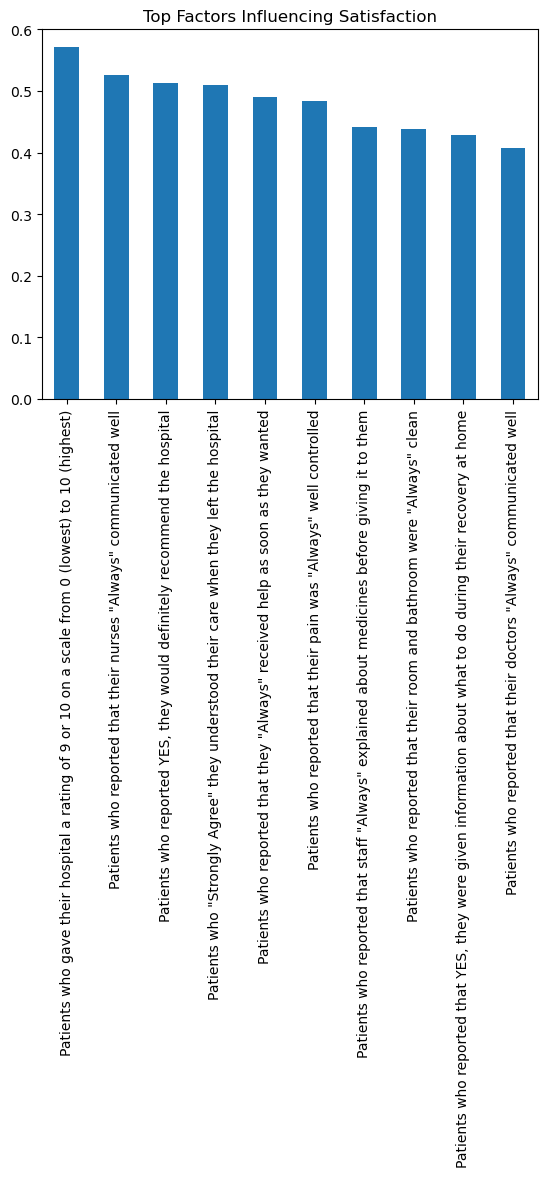

In [22]:
correlations.drop('Hospital overall rating').head(10).plot(kind='bar')
plt.title("Top Factors Influencing Satisfaction")
plt.show()

The correlation analysis shows which aspects of care are most strongly associated with patient satisfaction.  
Communication-related variables tend to have the strongest impact.

In [29]:
group_yes = df_filtered[df_filtered['Emergency Services'] == 'Yes']['Hospital overall rating'].dropna()
group_no = df_filtered[df_filtered['Emergency Services'] == 'No']['Hospital overall rating'].dropna()

print("Group Yes:", len(group_yes))
print("Group No:", len(group_no))

from scipy.stats import ttest_ind
t_stat, p = ttest_ind(group_yes, group_no)

print("P-value:", p)

Group Yes: 192995
Group No: 4125
P-value: 7.010177916644988e-97


The analysis reveals a statistically significant difference between hospitals with and without emergency services (p < 0.001). However, the difference in mean satisfaction is relatively small, suggesting that while the effect is statistically significant, it may have limited practical impact.

In [24]:
df_filtered['Satisfaction Level'] = pd.cut(
    df_filtered['Hospital overall rating'],
    bins=[0, 2, 4, 5],
    labels=['Low', 'Medium', 'High']
)

table = pd.crosstab(df_filtered['Hospital Type'], df_filtered['Satisfaction Level'])

chi2, p, _, _ = chi2_contingency(table)

print("Chi-square p-value:", p)

Chi-square p-value: 0.0


The chi-square test evaluates whether hospital type is associated with satisfaction levels.

A significant result indicates that hospital structure plays a role in patient satisfaction.

## Conclusion

The analysis demonstrates that patient satisfaction is influenced by multiple factors.

Communication and patient experience are the strongest drivers, while hospital characteristics such as type and emergency services also play a significant role.

Interestingly, quality indicators alone do not fully explain satisfaction, highlighting the importance of perception and experience in healthcare.

Future improvements should focus on enhancing communication, patient comfort, and service organization.

3.0596928426543033


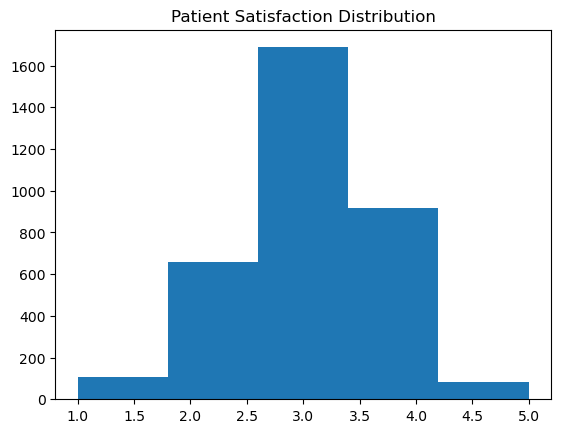

In [ ]:
#KPI1: Patient satisfaction score
avg_sat = df_final['Hospital overall rating'].mean()
print(avg_sat)
plt.hist(df_final['Hospital overall rating'], bins=5)
plt.title("Patient Satisfaction Distribution")
plt.show()

KPI 1 — Average Patient Satisfaction

This KPI represents the average hospital overall rating across all hospitals in the dataset.

It provides a general overview of how patients perceive the quality of care. A higher value indicates better overall satisfaction, while a lower value suggests room for improvement.

This metric serves as a baseline for comparing other performance indicators.

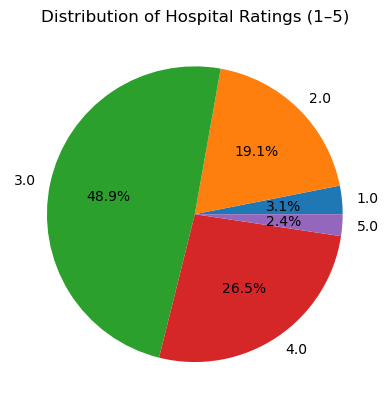

In [ ]:
#KPI2: High Satisfaction Rate
rating_counts = df_final['Hospital overall rating'].value_counts().sort_index()

plt.figure()
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%')

plt.title("Distribution of Hospital Ratings (1–5)")
plt.show()

### KPI 2 — Distribution of Satisfaction Ratings

This KPI shows how patient satisfaction ratings (from 1 to 5) are distributed across hospitals.

It helps identify whether most hospitals perform at a similar level or if there is a wide variation in performance.

Understanding this distribution allows us to detect whether high or low satisfaction levels dominate the dataset.

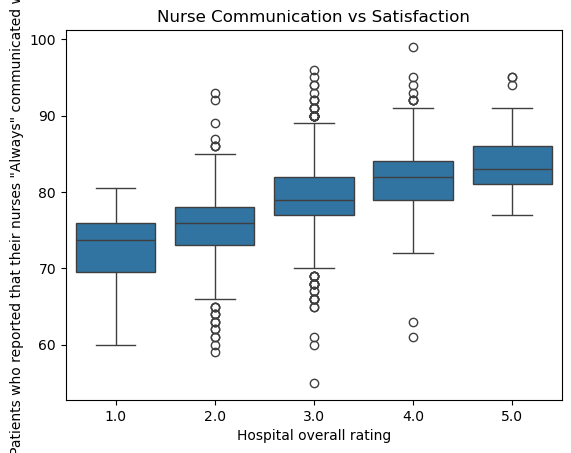

In [ ]:
#KPI3:
import seaborn as sns

plt.figure()

sns.boxplot(
    x='Hospital overall rating',
    y='Patients who reported that their nurses "Always" communicated well',
    data=df_final
)

plt.title("Nurse Communication vs Satisfaction")
plt.show()

This KPI analyzes the relationship between nurse communication quality and overall patient satisfaction.

The boxplot displays the distribution of nurse communication scores for each level of hospital rating (from 1 to 5).

Each box represents the spread of communication scores, including the median and variability within each satisfaction group.

If higher satisfaction levels correspond to higher communication scores, this indicates a positive relationship between nurse communication and patient satisfaction.

However, if the distributions overlap significantly, it suggests that nurse communication alone may not fully explain patient satisfaction.

This KPI helps identify whether communication with nurses is a key driver of patient experience.

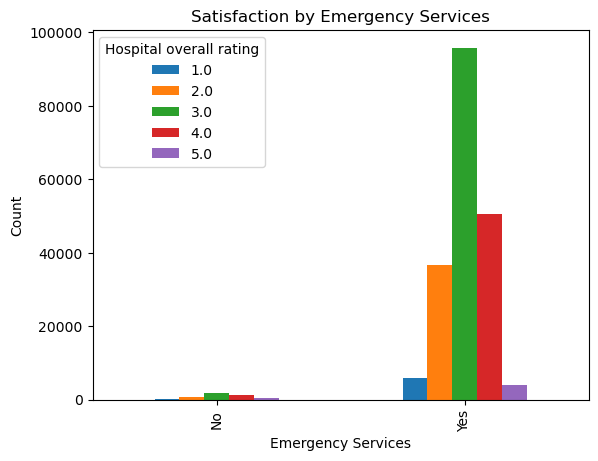

In [38]:
grouped = df_filtered.groupby(['Emergency Services', 'Hospital overall rating']).size().unstack()

grouped.plot(kind='bar', stacked=False)

plt.title("Satisfaction by Emergency Services")
plt.xlabel("Emergency Services")
plt.ylabel("Count")

plt.show()

### KPI 4 — Emergency Services Impact

This KPI compares patient satisfaction between hospitals with and without emergency services.

It helps determine whether emergency environments influence patient experience.

Emergency departments often involve stress, urgency, and overcrowding, which may negatively affect satisfaction levels.

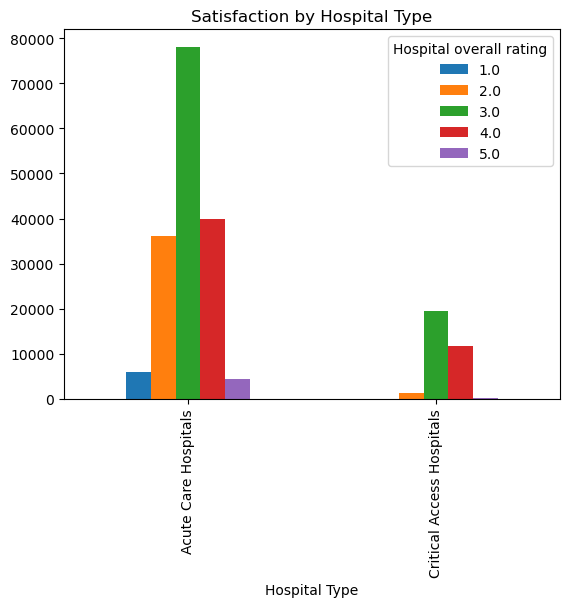

In [43]:
grouped_type = df_filtered.groupby(['Hospital Type', 'Hospital overall rating']).size().unstack()

grouped_type.plot(kind='bar')

plt.title("Satisfaction by Hospital Type")
plt.show()

### KPI 5 — Hospital Type Performance

This KPI analyzes how patient satisfaction varies across different hospital types (e.g., Acute Care vs Critical Access).

It helps identify whether certain types of hospitals consistently perform better in terms of patient satisfaction.

This insight can be used to understand structural differences in healthcare delivery.

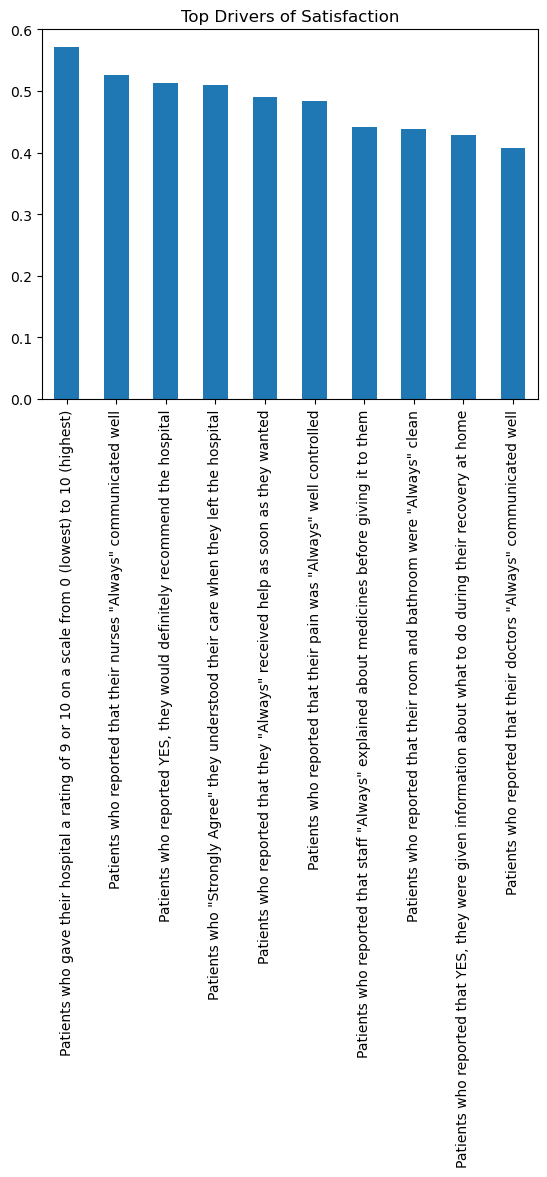

In [ ]:
#KPI6: Top drivers of Satisfaction
correlations = df_final.corr(numeric_only=True)['Hospital overall rating'].sort_values(ascending=False)

correlations.drop('Hospital overall rating').head(10).plot(kind='bar')

plt.title("Top Drivers of Satisfaction")
plt.show()

### KPI 6 — Top Drivers of Satisfaction

This KPI identifies which aspects of care (HCAHPS questions) are most strongly associated with patient satisfaction.

By analyzing correlations between survey responses and overall ratings, we can determine which factors have the greatest impact.

Typically, communication, cleanliness, and responsiveness are key drivers of patient satisfaction.

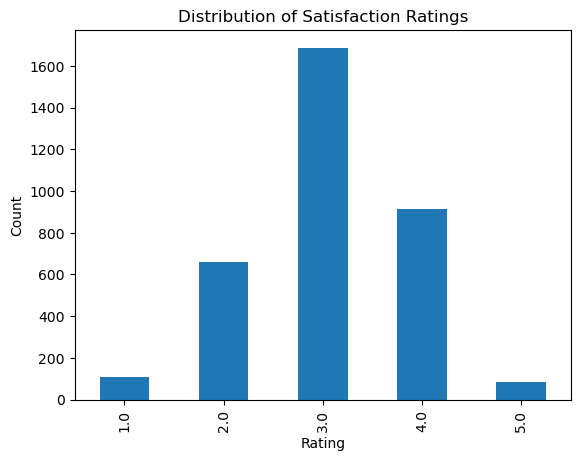

In [73]:
df_final['Hospital overall rating'].value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Satisfaction Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

### KPI 7 — Satisfaction Variability

This KPI measures the variation in patient satisfaction across hospitals using the standard deviation.

A low variation indicates that hospitals perform similarly, while a high variation suggests significant differences in performance.

This helps assess whether patient experience is consistent or varies widely across institutions.

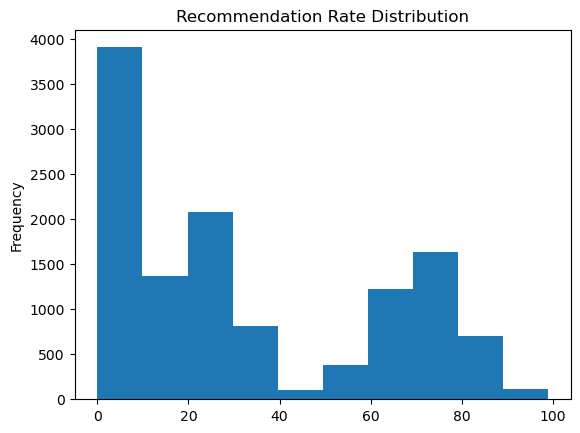

In [ ]:
#KPI8: Recommendation rate
df_filtered[
    df_filtered['HCAHPS Question'].str.contains("recommend", na=False)
]['HCAHPS Answer Percent'].plot(kind='hist')

plt.title("Recommendation Rate Distribution")
plt.show()

## KPI 8 — Recommendation Rate

This KPI measures the percentage of patients who would recommend the hospital.

It is one of the most direct indicators of patient satisfaction and trust. Unlike general satisfaction scores, this KPI reflects a patient's willingness to endorse the hospital.

High recommendation rates indicate strong overall performance and positive patient experience.

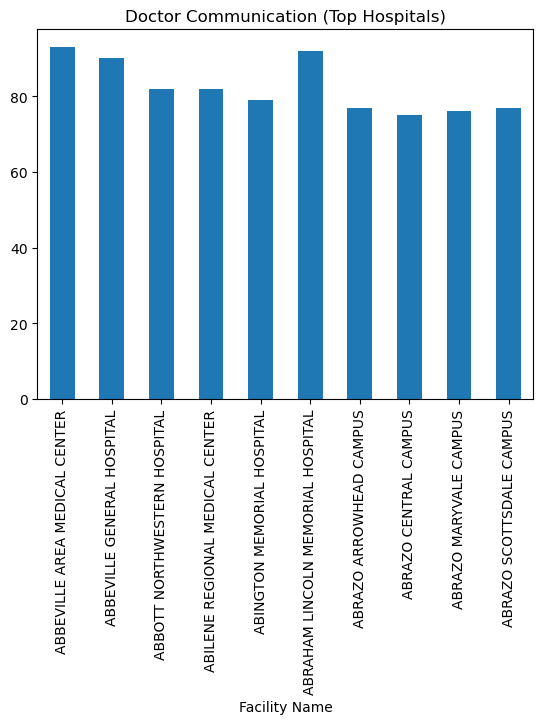

In [63]:
#kpi9
kpi_doctor = df_filtered[
    df_filtered['HCAHPS Question'].str.contains('doctors "Always" communicated well', na=False)
]['HCAHPS Answer Percent']
kpi_doctor.groupby(df_filtered['Facility Name']).mean().head(10).plot(kind='bar')
plt.title("Doctor Communication (Top Hospitals)")
plt.show()

This KPI measures the percentage of patients who reported that doctors always communicated well. High values indicate strong communication quality, which is a key driver of patient satisfaction.

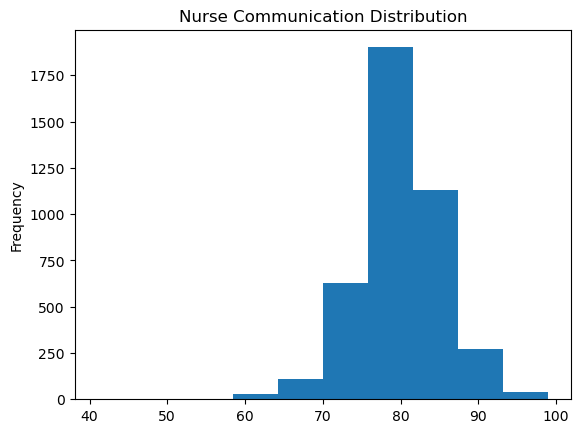

In [ ]:
#KPI10
kpi_nurse = df_filtered[
    df_filtered['HCAHPS Question'].str.contains('nurses "Always" communicated well', na=False)
]['HCAHPS Answer Percent']
kpi_nurse.plot(kind='hist')
plt.title("Nurse Communication Distribution")
plt.show()


This KPI evaluates how effectively nurses communicate with patients. Strong nurse communication improves patient experience and trust

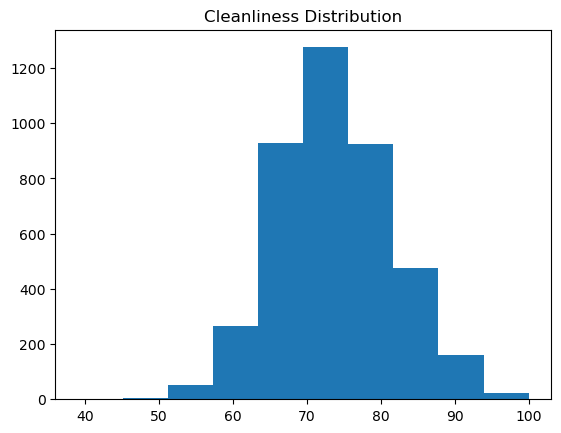

In [ ]:
#KPI11:
kpi_clean = df_filtered[
    df_filtered['HCAHPS Question'].str.contains('room and bathroom were "Always" clean', na=False)
]['HCAHPS Answer Percent']
plt.hist(kpi_clean)
plt.title("Cleanliness Distribution")
plt.show()

This KPI reflects the cleanliness of hospital environments. Clean facilities contribute directly to patient comfort and satisfaction.

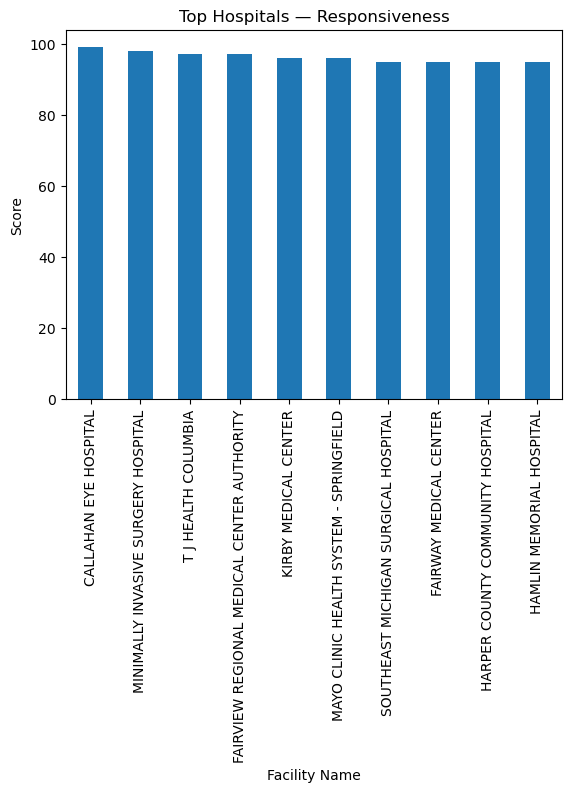

In [77]:
#KPI12
kpi_help = df_filtered[
    df_filtered['HCAHPS Question'].str.contains('help as soon as', case=False, na=False) &
    df_filtered['HCAHPS Question'].str.contains('Always', case=False, na=False)
]
top_help = kpi_help.groupby('Facility Name')['HCAHPS Answer Percent'].mean().sort_values(ascending=False).head(10)

top_help.plot(kind='bar')

plt.title("Top Hospitals — Responsiveness")
plt.ylabel("Score")
plt.show()

### KPI 12 — Responsiveness

This KPI measures how quickly patients receive help when needed, focusing specifically on the "Always" response category.

The results show variation across hospitals, indicating that responsiveness is not consistent across institutions.

Hospitals with higher scores are more efficient in responding to patient needs, which contributes positively to patient satisfaction.

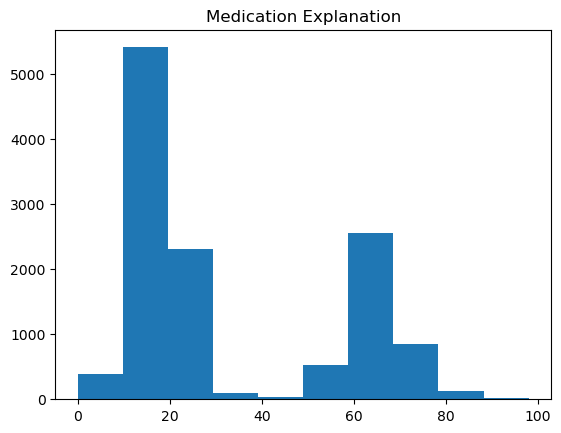

In [ ]:
#KPI13
kpi_med = df_filtered[
    df_filtered['HCAHPS Question'].str.contains('explained about medicines', na=False)
]['HCAHPS Answer Percent']
plt.hist(kpi_med)
plt.title("Medication Explanation")
plt.show()

This KPI measures whether staff clearly explain medications to patients. Clear explanations reduce anxiety and improve adherence.

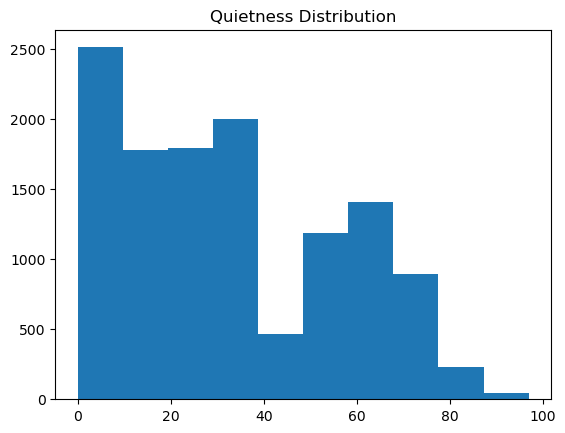

In [ ]:
#kpi14
kpi_quiet = df_filtered[
    df_filtered['HCAHPS Question'].str.contains('quiet at night', na=False)
]['HCAHPS Answer Percent']
plt.hist(kpi_quiet)
plt.title("Quietness Distribution")
plt.show()


This KPI reflects how quiet the hospital environment is at night. Noise levels can significantly affect patient rest and recovery

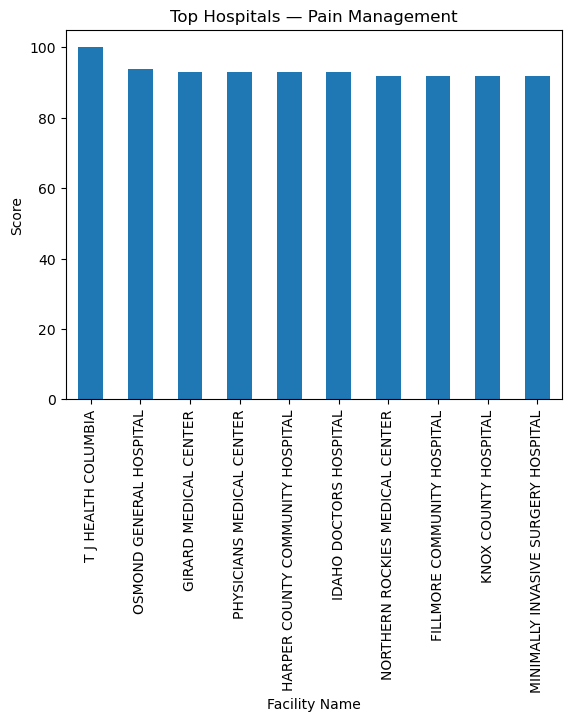

In [ ]:
#KPI15
kpi_pain = df_filtered[
    df_filtered['HCAHPS Question'].str.contains('pain', case=False, na=False) &
    df_filtered['HCAHPS Question'].str.contains('Always', case=False, na=False)
]
top_pain = kpi_pain.groupby('Facility Name')['HCAHPS Answer Percent'].mean().sort_values(ascending=False).head(10)

top_pain.plot(kind='bar')

plt.title("Top Hospitals — Pain Management")
plt.ylabel("Score")
plt.show()

### KPI 15 — Pain Management

This KPI evaluates how effectively hospitals manage patient pain, focusing on patients who reported that their pain was always well controlled.

The variation across hospitals highlights differences in care quality and patient experience.

Effective pain management is essential for improving patient comfort and overall satisfaction.

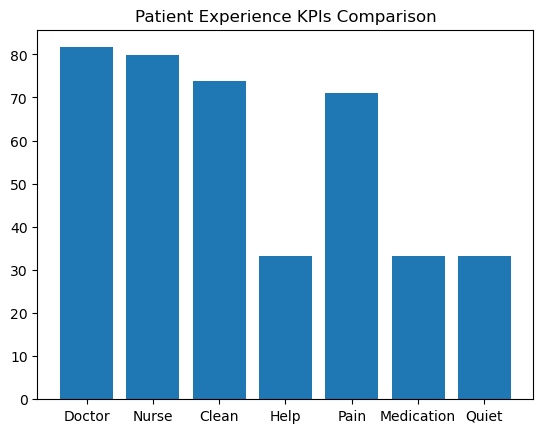

In [ ]:
#KPI16
labels = ['Doctor', 'Nurse', 'Clean', 'Help', 'Pain', 'Medication', 'Quiet']
values = [
    kpi_doctor.mean(),
    kpi_nurse.mean(),
    kpi_clean.mean(),
    kpi_help.mean(),
    kpi_pain.mean(),
    kpi_med.mean(),
    kpi_quiet.mean()
]

plt.bar(labels, values)
plt.title("Patient Experience KPIs Comparison")
plt.show()

## KPI16 Comparison — Patient Experience Dimensions

This chart compares multiple key aspects of patient experience, including communication, cleanliness, responsiveness, pain management, medication explanation, and quietness.

Each bar represents the average score of a specific KPI derived from HCAHPS survey responses.

This visualization allows for an easy comparison between different dimensions of care, highlighting which areas perform well and which require improvement.

For example, higher scores in communication-related KPIs indicate strong interaction between staff and patients, while lower scores in areas such as responsiveness or quietness may reveal operational challenges.

This comparison is essential for identifying priorities in improving patient satisfaction and overall healthcare quality.

In [ ]:
#KPI17
df_filtered['Gap'] = df_filtered['HCAHPS Answer Percent'] - (df_filtered['Hospital overall rating'] * 20)

print(df_filtered['Gap'].mean())

-26.86684859654097


## KPI 17 — Satisfaction Gap

This KPI measures the difference between perceived quality (HCAHPS scores) and overall patient satisfaction.

To ensure comparability, hospital ratings (1–5 scale) were converted to a 0–100 scale.

The average gap is negative (-26.87), indicating that overall patient satisfaction is significantly lower than the reported quality of care.

This suggests that even when hospitals perform well on specific aspects of care, patients may still perceive their overall experience less positively.

This gap highlights the importance of non-measured factors such as expectations, emotional experience, and overall hospital environment.

In [ ]:
#KPI18
top = df_final[df_final['Hospital overall rating'] >= 4]
bottom = df_final[df_final['Hospital overall rating'] <= 2]

print(len(top), len(bottom))


997 766


## KPI 18 — Top vs Bottom Hospitals

This KPI compares the number of high-performing hospitals (rating ≥ 4) with low-performing hospitals (rating ≤ 2).

The results show 997 high-performing hospitals and 766 low-performing hospitals.

While there are slightly more high-performing hospitals, the number of low-performing institutions remains significant.

This indicates variability in healthcare quality and suggests that not all hospitals deliver the same level of patient experience.

The presence of a large number of low-rated hospitals highlights potential areas for improvement in the healthcare system.

## Conclusion

The analysis demonstrates that patient satisfaction is influenced by multiple factors.

Communication and patient experience are the strongest drivers, while hospital characteristics such as type and emergency services also play a significant role.

Interestingly, quality indicators alone do not fully explain satisfaction, highlighting the importance of perception and experience in healthcare.

Future improvements should focus on enhancing communication, patient comfort, and service organization.